In [1]:
import networkx as nx
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import powerlaw
warnings.filterwarnings('ignore')

In [2]:
nodes = pd.read_csv('twitch_nodes_10k_final.csv')

In [3]:
edges = pd.read_csv('twitch_edgelist_10k.csv')

In [4]:
G = nx.Graph()  # Crea un grafo vuoto
for _, row in nodes.iterrows():
    G.add_node(row['ID'], 
               label=row['Label'], 
               type=row['Broadcaster_Type'], 
               followers=row['Total_Followers'])
for _, row in edges.iterrows():
    G.add_edge(row['Source'], row['Target'], weight=row['Weight'])

In [5]:
#map G to G_name
G_name = nx.relabel_nodes(G, {node: G.nodes[node]['label'] for node in G.nodes()})

In [6]:
#top 5000
sub_G = G.subgraph(list(G.nodes)[:5000])

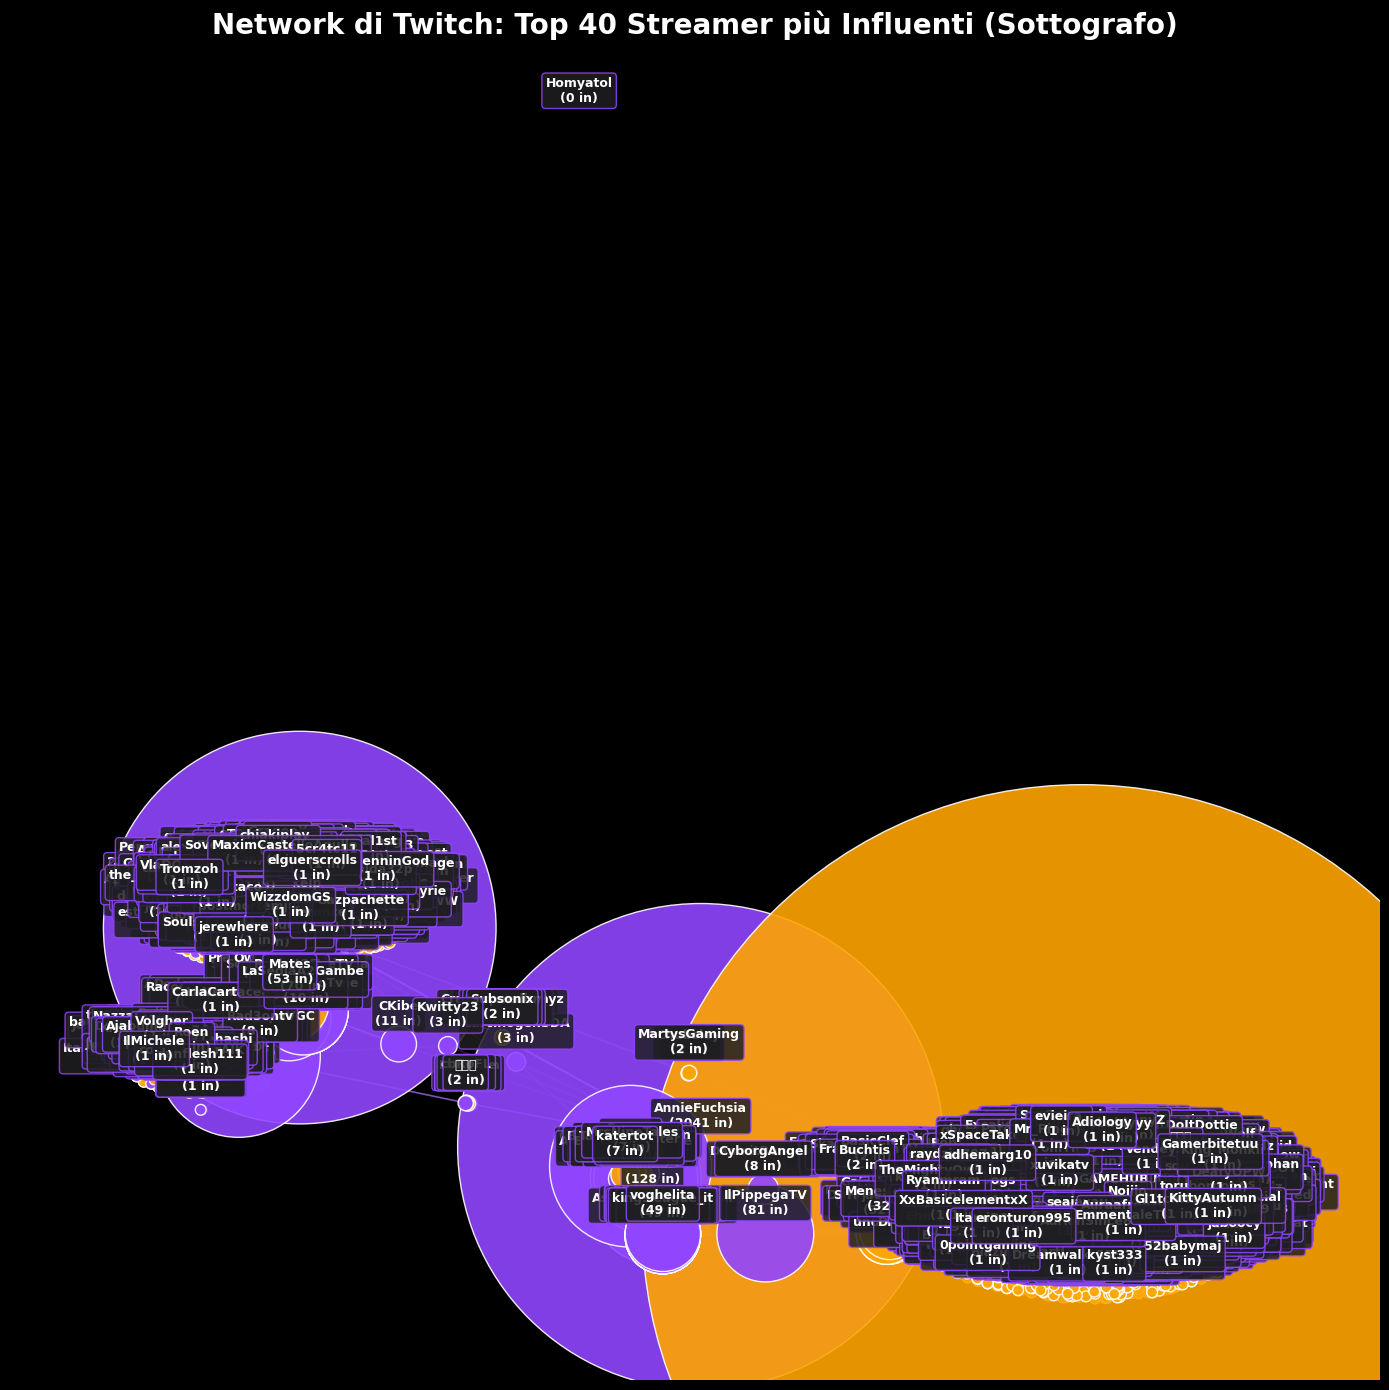

In [ ]:
fig, ax = plt.subplots(figsize=(14, 14), facecolor='black')
ax.set_facecolor('black')
pos = nx.spring_layout(sub_G, seed=42)
node_sizes = [G.degree(n) * 60 for n in sub_G.nodes]
colors = ['#9146FF' if sub_G.nodes[n]['type'] == 'partner' else '#ffa500' for n in sub_G.nodes]
nx.draw_networkx_edges(
    sub_G, pos, ax=ax,
    alpha=0.25,                 
    edge_color='#a970ff',
    connectionstyle='arc3,rad=0.1' 
)

# Nodi
nx.draw_networkx_nodes(
    sub_G, pos, ax=ax,
    node_size=node_sizes,
    node_color=colors,
    alpha=0.9,
    edgecolors='#ffffff',
    linewidths=1
)
# Etichette
for node, (x, y) in pos.items():
    deg = G.degree(node)
    label_text = f"{sub_G.nodes[node]['label']}\n({deg} in)"
    ax.text(
        x, y + 0.03,             # Leggero offset verticale rispetto al centro del nodo
        s=label_text,
        color='white',
        fontsize=9,
        fontweight='bold',
        horizontalalignment='center',
        verticalalignment='center',
        bbox=dict(facecolor='#1f1f23', edgecolor='#9146FF', boxstyle='round,pad=0.3', alpha=0.85)
    )

ax.set_title("Network di Twitch: Top 40 Streamer più Influenti (Sottografo)", fontsize=20, color='white', fontweight='bold', pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()

In [8]:
nx.write_gexf(G, "grafo_twitch_completo_und.gexf")

# Understanding

In [9]:
G.number_of_nodes()

10356

In [10]:
G.number_of_edges()

14192

In [11]:
G.is_directed()

False

## Degrees and Degree Distribution

In [12]:
G_name.degree('Tumblurr')

49

In [13]:
sum(dict(G.degree()).values())/float(len(G))

2.7408265739667828

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 24/24 [00:00<00:00, 773.43it/s]

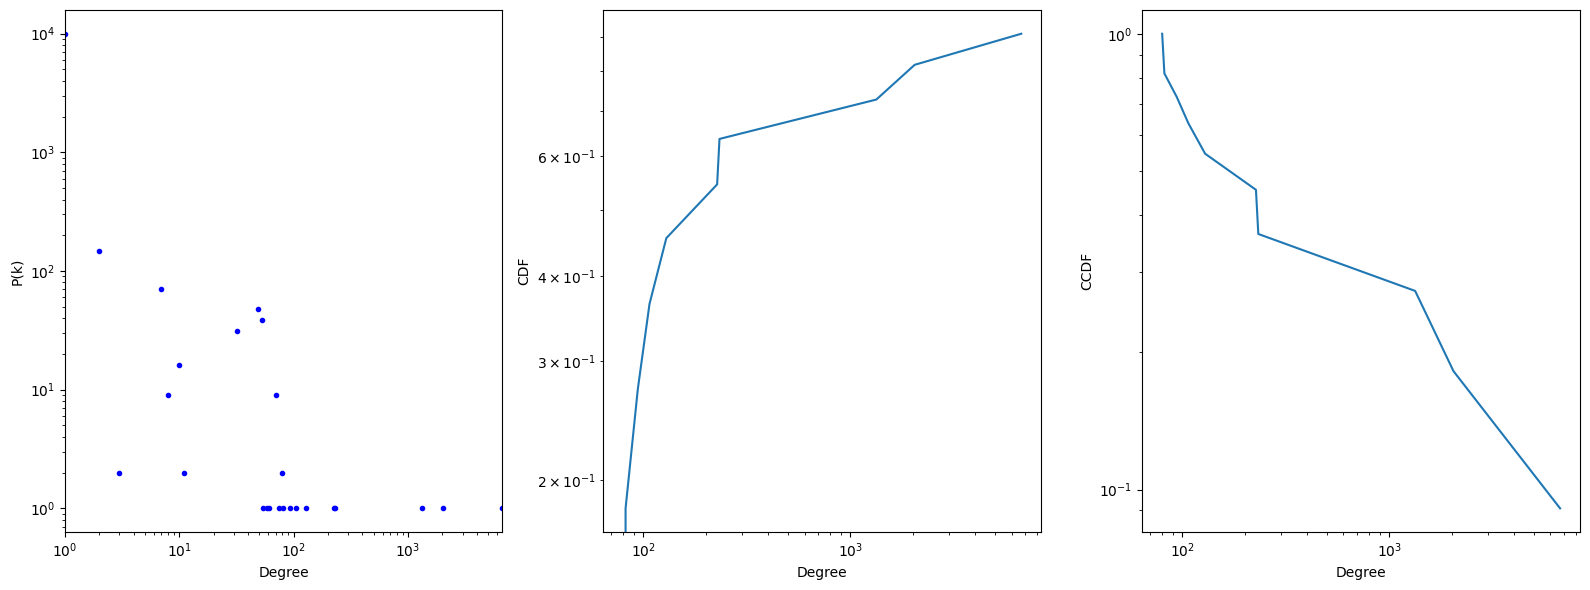

In [14]:
def plot_dist(G):
    M = nx.to_scipy_sparse_array(G)
    xmin = min([d[1] for d in G.degree()])
    
    degree_sequence = np.asarray(M.sum(axis=0)).ravel().astype(int)   # grado di ciascun nodo
    degree_distribution = np.bincount(degree_sequence)                 # n. di nodi per ogni valore di grado
    
    degs = np.array([d for _, d in G.degree()])
    fit = powerlaw.Fit(degs + 1, discrete=True, fit_method='KS')

    
    fig = plt.figure(figsize=(16, 6)) 
    """ Plot Distribution """
    plt.subplot(1, 3, 1)
    plt.plot(range(len(degree_distribution)), degree_distribution, 'b.')   
    plt.loglog()
    plt.xlim(1, degree_sequence.max())
    plt.xlabel('Degree')
    plt.ylabel('P(k)')

    """ Plot CDF """
    plt.subplot(1, 3, 2)
    fit.plot_cdf()
    plt.xlabel("Degree")
    plt.ylabel('CDF')

    """ Plot CCDF """
    plt.subplot(1, 3, 3)
    fit.plot_ccdf()
    plt.ylabel('CCDF')
    plt.xlabel('Degree')
    plt.tight_layout()
    plt.show()

plot_dist(G)

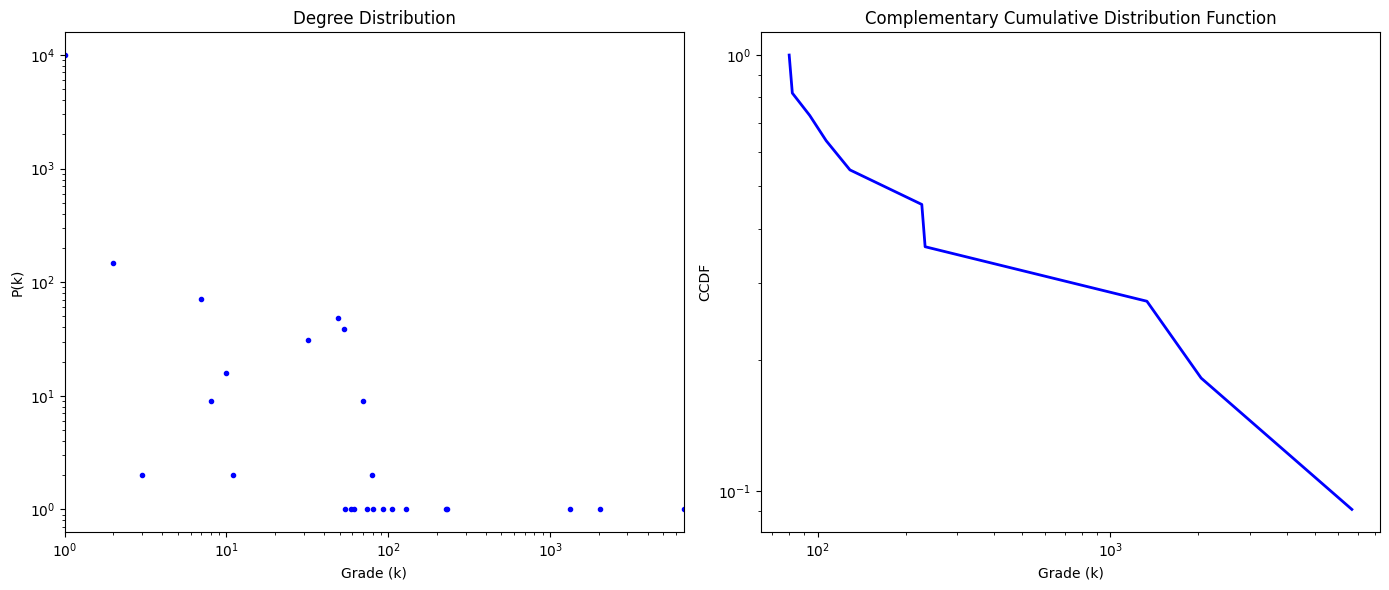

In [ ]:
def plot_dist(G):

    M = nx.to_scipy_sparse_array(G)
    degree_sequence = np.asarray(M.sum(axis=0)).ravel().astype(int)
    degree_distribution = np.bincount(degree_sequence)
    
    #fit powerlaw
    degs = np.array([d for _, d in G.degree()])
    fit = powerlaw.Fit(degs + 1, discrete=True, fit_method='KS', verbose=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
    
    axes[0].plot(range(len(degree_distribution)), degree_distribution, 'b.')   
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_xlim(1, degree_sequence.max())
    axes[0].set_xlabel('Grade (k)')
    axes[0].set_ylabel('P(k)')
    axes[0].set_title('Degree Distribution')

    fit.plot_ccdf(ax=axes[1], color='b', linewidth=2)
    axes[1].set_xlabel('Grade (k)')
    axes[1].set_ylabel('CCDF')
    axes[1].set_title('Complementary Cumulative Distribution Function')
    
    plt.tight_layout()
    plt.show()
plot_dist(G)

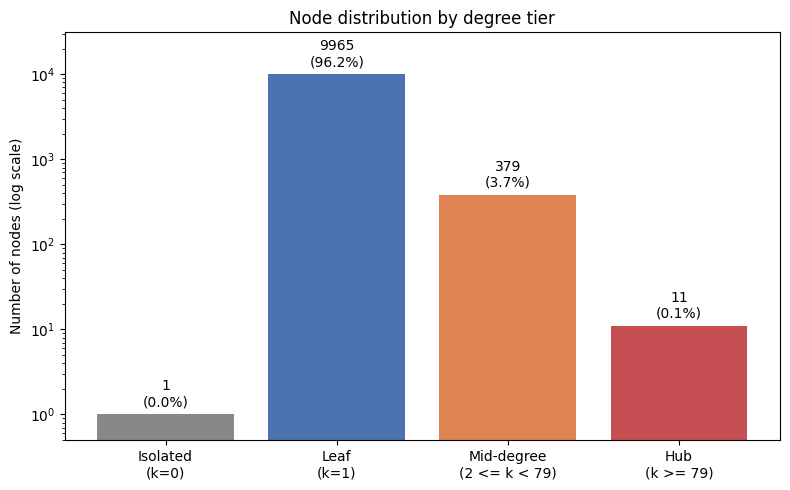

In [16]:
degs = np.array([d for _, d in G.degree()])
N = len(degs)

categories = ['Isolated\n(k=0)', 'Leaf\n(k=1)', 'Mid-degree\n(2 <= k < 79)', 'Hub\n(k >= 79)']
counts = [
    (degs==0).sum(),
    (degs==1).sum(),
    ((degs>=2)&(degs<79)).sum(),
    (degs>=79).sum(),
]
pct = [100*c/N for c in counts]

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(categories, counts, color=['#888888','#4C72B0','#DD8452','#C44E52'])
ax.set_yscale('log')
ax.set_ylabel('Number of nodes (log scale)')
ax.set_title('Node distribution by degree tier')

for bar, c, p in zip(bars, counts, pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.15,
            f'{c}\n({p:.1f}%)', ha='center', va='bottom', fontsize=10)

ax.set_ylim(0.5, N*3)
plt.tight_layout()
plt.show()

## Graph components

In [17]:
list(G_name.neighbors('ilGattoSulTubo'))

['POW3R',
 'Darkhim',
 'Parliamodivg',
 'Sabaku_no_Sutoriimaa',
 'Mates',
 'DogOut_Family',
 'Cydonia_Chiara',
 'ElitGamingOfficial',
 'Gioee',
 'pixelkewie',
 'RandyRenna',
 'Poldo',
 'Phenrir_Mailoki',
 'Rocket25_',
 'Kurolily',
 'InnTale',
 'slimdogsproduction',
 'BisUmTo',
 'SoloUmido',
 'Demitat',
 'HALtv',
 'mansi',
 'LeonardoBru',
 'Gidano',
 'danny_lazzarin',
 'Zanzo_Official',
 'BertraTV',
 'Naaklin',
 'ErenBlaze',
 'LaSediaA2Gambe',
 'Hemerald',
 'Babbalucy',
 'LeonasTV',
 'GOA7League',
 'Crappo_live',
 'delia_',
 'sbuci',
 'Fierik',
 'SchiacciSempreTV',
 'Sbriser',
 'Yotobi',
 'Yucali',
 'Kroatomist',
 'Dlarzz',
 'francesca_cuccuru',
 'TearlessRaptor',
 'iTermosifoni',
 'Terenas',
 'GoEaSyTwitch',
 'Totta',
 '151eg',
 'ocwsport',
 'Rixel_official']

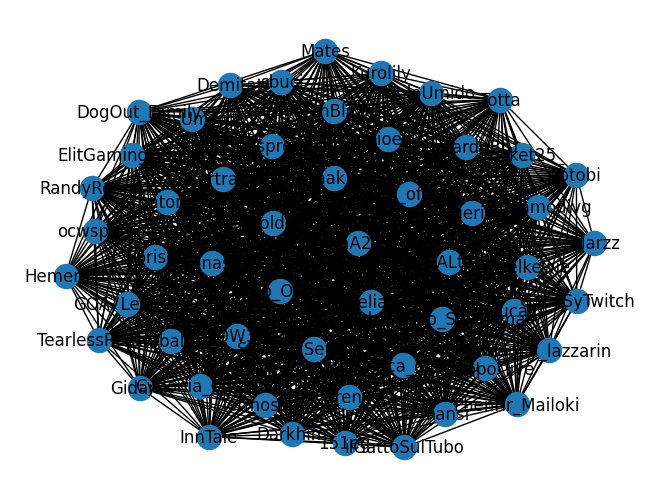

In [18]:
ego = nx.ego_graph(G_name, 'Gioee') # ego network of the node 0
nx.draw(ego, with_labels=True)

In [19]:
nx.number_connected_components(G)

2

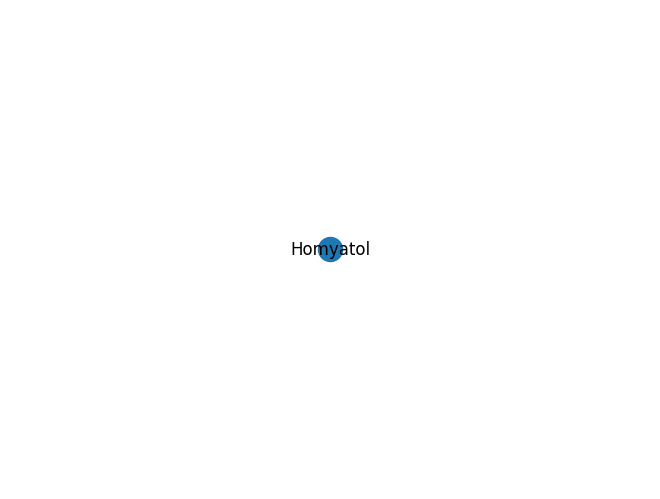

In [ ]:
comps = list(nx.connected_components(G_name))
comp_1 = nx.subgraph(G_name, comps[1])
nx.draw(comp_1, with_labels=True)

In [ ]:
homyatol_id = None
for node, attrs in G.nodes(data=True):
    if str(attrs.get('label')).lower() == 'homyatol':
        homyatol_id = node
        break
if homyatol_id is not None:
    G.remove_node(homyatol_id)

# Paths and Diameter

In [21]:
nx.shortest_path(G_name, 'Gioee', 'Kurolily')

['Gioee', 'Kurolily']

In [22]:
nx.shortest_path_length(G_name, 'Gioee', 'Kurolily')

1

In [23]:
nx.diameter(G_name.subgraph(comps[0]))

7

## Triangles, density and clustering

In [24]:
nx.density(G)

0.0002646862939610606

In [25]:
nx.triangles(G_name)['Kurolily']

1531

In [26]:
nx.clustering(G_name)['Kurolily'] #local clustering coefficient

0.6339544513457557

In [27]:
nx.average_clustering(G) 

0.024389205914744555

# Confronto con Erdős–Rényi e Barabási–Albert

In [28]:
import random

N = G.number_of_nodes()
E = G.number_of_edges()
avg_k = 2 * E / N

random.seed(1)
np.random.seed(1)

# Erdos-Renyi: stessa N, stessa densita' osservata (p = densita' reale)
p_er = nx.density(G)
G_er = nx.gnp_random_graph(N, p_er, seed=1)

# Barabasi-Albert: il modello standard permette solo m intero (grado medio = 2m),
# ma il grado medio reale (2.74) non è un multiplo intero di 2.
# Uso il "dual" BA che mescola m1 e m2 archi per nuovo nodo per ottenere
# un grado medio frazionario: p*m1 + (1-p)*m2 = avg_k
m1, m2, p_mix = 1, 2, 0.63   # 0.63*1 + 0.37*2 = 2.74
G_ba = nx.dual_barabasi_albert_graph(N, m1, m2, p_mix, seed=1)

models = {'Reale': G, 'Erdos-Renyi': G_er, 'Barabasi-Albert': G_ba}

In [ ]:
def network_summary(G, label, n_sample=300, seed=42):
    N_, E_ = G.number_of_nodes(), G.number_of_edges()
    comps = sorted(nx.connected_components(G), key=len, reverse=True)
    Gc = G.subgraph(comps[0])

    random.seed(seed)
    sample = random.sample(list(Gc.nodes()), min(n_sample, len(Gc)))
    tot, cnt, ecc = 0, 0, 0
    for n in sample:
        lengths = nx.single_source_shortest_path_length(Gc, n)
        tot += sum(lengths.values())
        cnt += len(lengths) - 1
        ecc = max(ecc, max(lengths.values()))

    degs = np.array([d for _, d in G.degree()])

    degs_fit = degs[degs > 0]
    fit = powerlaw.Fit(degs_fit, discrete=True, fit_method='KS', verbose=False)
    R, p = fit.distribution_compare('power_law', 'exponential')

    return {
        'Rete': label, 
        'N': N_, 
        'E': E_,
        'Grado massimo': np.max(degs), # Aggiunto per il confronto sugli Hubs
        'Grado medio': round(2 * E_ / N_, 4),
        'Densità': round(nx.density(G), 6),
        'Clustering medio': round(nx.average_clustering(G), 4),
        '# Componenti': len(comps),
        'Comp. gigante (%)': round(100 * len(comps[0]) / N_, 2),
        'Path medio (stima)': round(tot / cnt, 2),
        'Ecc. max campione': ecc,
        'alpha (power law)': round(fit.alpha, 2),
        'LR (PL vs Exp)': round(R, 2), 
        'p-value': round(p, 4)
    }

df_summary = pd.DataFrame([network_summary(g, name) for name, g in models.items()]).set_index('Rete').T
df_summary

Rete,Reale,Erdos-Renyi,Barabasi-Albert
N,10356.000000,10356.000000,10356.000000
E,14192.000000,14285.000000,14098.000000
Grado massimo,6680.000000,12.000000,237.000000
Grado medio,2.740800,2.758800,2.722700
Densità,0.000265,0.000266,0.000263
Clustering medio,0.024400,0.000500,0.001800
# Componenti,2.000000,717.000000,1.000000
Comp. gigante (%),99.990000,92.260000,100.000000
Path medio (stima),3.110000,9.030000,5.960000
Ecc. max campione,7.000000,20.000000,13.000000
